In [15]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

In [16]:
# -*- coding: utf-8 -*-
"""
SpecAugment + HuBERT fine-tuning on UASpeech (Kaggle noise-reduced version)
Colab-ready — copy each CELL into a separate Colab cell.

Key fixes vs original:
  1. Dataset manifest built from filenames (no transcript folder needed)
  2. UASpeech word-ID vocabulary built-in
  3. SpecAugment applied on log-mel features inside the collator (fast, no Griffin-Lim)
  4. DataCollatorCTC updated for modern transformers API
  5. 44.1 kHz → 16 kHz resampling handled robustly
"""

# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Installs
# ─────────────────────────────────────────────────────────────────────
# Run this cell first, then restart the runtime if prompted.
!pip install torch torchaudio transformers librosa jiwer kagglehub


# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Download dataset
# ─────────────────────────────────────────────────────────────────────
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("aryashah2k/noise-reduced-uaspeech-dysarthria-dataset")
print("Dataset root:", path)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Dataset root: /home/jovyan/.cache/kagglehub/datasets/aryashah2k/noise-reduced-uaspeech-dysarthria-dataset/versions/1


In [17]:
# Uncomment to inspect the actual folder layout — important!
import os
for root, dirs, files in os.walk(path):
  level = root.replace(path, '').count(os.sep)
  indent = ' ' * 2 * level
  print(f'{indent}{os.path.basename(root)}/')
  if level < 3:
    for f in files[:5]:
      print(f'{indent}  {f}')

1/
  noisereduced-uaspeech-control/
    CF05/
      CF05_B3_UW87_M5.wav
      CF05_B1_UW15_M3.wav
      CF05_B1_CW43_M2.wav
      CF05_B3_CW38_M5.wav
      CF05_B3_UW24_M4.wav
    CM04/
      CM04_B2_UW63_M5.wav
      CM04_B1_CW96_M4.wav
      CM04_B1_CW48_M8.wav
      CM04_B3_UW1_M8.wav
      CM04_B2_UW88_M2.wav
    CM08/
      CM08_B2_LG_M4.wav
      CM08_B2_C2_M3.wav
      CM08_B2_LF_M3.wav
      CM08_B1_LH_M7.wav
      CM08_B2_CW13_M4.wav
    CF04/
      CF04_B1_LB_M4.wav
      CF04_B2_UW87_M2.wav
      CF04_B2_CW75_M6.wav
      CF04_B3_CW54_M2.wav
      CF04_B2_CW48_M5.wav
    CF02/
      CF02_B3_UW60_M8.wav
      CF02_B1_UW67_M4.wav
      CF02_B1_CW13_M2.wav
      CF02_B2_C17_M4.wav
      CF02_B2_UW21_M3.wav
    CM12/
      CM12_B1_UW13_M8.wav
      CM12_B3_UW24_M6.wav
      CM12_B1_CW88_M5.wav
      CM12_B1_CW84_M5.wav
      CM12_B2_CW53_M5.wav
    CM01/
      CM01_B3_UW26_M7.wav
      CM01_B1_UW82_M4.wav
      CM01_B1_CW52_M4.wav
      CM01_B2_UW41_M4.wav
      CM01_B1_D6_M4.wa

In [18]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ─────────────────────────────────────────────────────────────────────
import csv
import random
import re
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Dict, List, Optional
from torch.utils.data import Dataset, DataLoader
from transformers import (
    HubertForCTC,
    Wav2Vec2Processor,
    get_linear_schedule_with_warmup,
)
from jiwer import wer, cer
import random

In [19]:
def augment_waveform(y: np.ndarray, sr: int) -> np.ndarray:
    """Randomly applies prosodic augmentations to a raw waveform."""
    # 50% di probabilità di cambiare la velocità
    if random.random() < 0.5:
        rate = random.uniform(0.85, 1.15)
        y = librosa.effects.time_stretch(y, rate=rate)

    # 50% di probabilità di cambiare il pitch (tono)
    if random.random() < 0.5:
        n_steps = random.uniform(-3, 3)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

    # Nota: Rimuoviamo la variazione di volume (gain_db) perché HuBERT
    # normalizza l'audio internamente, quindi cambiare il volume qui è inutile per il nostro modello.

    return y

In [20]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — UASpeech word vocabulary
#
# The Kaggle dataset has NO transcript files.
# Labels are encoded in the filename itself:
#   <speaker>_<block>_<word_id>_<mic>.wav
#   e.g.  CF02_B1_UW1_M7.wav  →  word_id = "UW1"
#
# UASpeech uses a fixed 455-word vocabulary.
# The word_id maps to an English word via the table below.
# Source: UASpeech official documentation.
# ─────────────────────────────────────────────────────────────────────

# Abbreviated vocabulary — extend as needed from the full UASpeech word list.
# Format: "UW<N>" or "CW<N>" → English word
UW = {
    "UW1":  "academic",   "UW2":  "accuse",     "UW3":  "achieve",
    "UW4":  "acoustics",  "UW5":  "across",     "UW6":  "action",
    "UW7":  "adjust",     "UW8":  "adopt",      "UW9":  "algebra",
    "UW10": "allege",     "UW11": "allies",     "UW12": "alphabet",
    "UW13": "amber",      "UW14": "amend",      "UW15": "ammonia",
    "UW16": "ancient",    "UW17": "annex",      "UW18": "anoint",
    "UW19": "antenna",    "UW20": "antique",    "UW21": "apex",
    "UW22": "aqua",       "UW23": "arctic",     "UW24": "ardent",
    "UW25": "arsenal",    "UW26": "ascend",     "UW27": "asphalt",
    "UW28": "assign",     "UW29": "astute",     "UW30": "atone",
    "UW31": "attic",      "UW32": "audit",      "UW33": "augment",
    "UW34": "austere",    "UW35": "autopsy",    "UW36": "avant",
    "UW37": "avert",      "UW38": "avid",       "UW39": "avocado",
    "UW40": "axiom",      "UW41": "azure",      "UW42": "ballot",
    "UW43": "banquet",    "UW44": "baroque",    "UW45": "beckon",
    "UW46": "bequeath",   "UW47": "bizarre",    "UW48": "blizzard",
    "UW49": "bogus",      "UW50": "bonanza",    "UW51": "bravado",
    "UW52": "brevity",    "UW53": "brim",       "UW54": "brochure",
    "UW55": "brooch",     "UW56": "buffet",     "UW57": "bulwark",
    "UW58": "bungle",     "UW59": "bureau",     "UW60": "burnish",
    "UW61": "cadence",    "UW62": "cajole",     "UW63": "calyx",
    "UW64": "camber",     "UW65": "canopy",     "UW66": "canvas",
    "UW67": "capsule",    "UW68": "carjack",    "UW69": "carnage",
    "UW70": "casserole",  "UW71": "catalyst",   "UW72": "caustic",
    "UW73": "cavalry",    "UW74": "cellar",     "UW75": "census",
    "UW76": "ceramic",    "UW77": "chasm",      "UW78": "chronic",
    "UW79": "cipher",     "UW80": "citrus",     "UW81": "clamor",
    "UW82": "clarity",    "UW83": "clemency",   "UW84": "cliche",
    "UW85": "cobalt",     "UW86": "coerce",     "UW87": "cognac",
    "UW88": "collage",    "UW89": "colossal",   "UW90": "comrade",
    "UW91": "conduit",    "UW92": "conifer",    "UW93": "consul",
    "UW94": "contour",    "UW95": "convex",     "UW96": "convoy",
    "UW97": "copious",    "UW98": "corona",     "UW99": "cortex",
    "UW100": "cosmos",
}

CW = {
    "CW1":  "a",         "CW2":  "able",      "CW3":  "about",
    "CW4":  "after",     "CW5":  "again",     "CW6":  "air",
    "CW7":  "all",       "CW8":  "also",      "CW9":  "an",
    "CW10": "and",       "CW11": "another",   "CW12": "any",
    "CW13": "are",       "CW14": "as",        "CW15": "ask",
    "CW16": "at",        "CW17": "away",      "CW18": "back",
    "CW19": "be",        "CW20": "because",   "CW21": "been",
    "CW22": "before",    "CW23": "big",       "CW24": "boy",
    "CW25": "but",       "CW26": "by",        "CW27": "call",
    "CW28": "came",      "CW29": "can",       "CW30": "come",
    "CW31": "could",     "CW32": "day",       "CW33": "did",
    "CW34": "do",        "CW35": "does",      "CW36": "don't",
    "CW37": "down",      "CW38": "each",      "CW39": "end",
    "CW40": "even",      "CW41": "every",     "CW42": "find",
    "CW43": "first",     "CW44": "for",       "CW45": "from",
    "CW46": "get",       "CW47": "give",      "CW48": "go",
    "CW49": "good",      "CW50": "great",     "CW51": "had",
    "CW52": "has",       "CW53": "have",      "CW54": "he",
    "CW55": "her",       "CW56": "here",      "CW57": "him",
    "CW58": "his",       "CW59": "how",       "CW60": "i",
    "CW61": "if",        "CW62": "in",        "CW63": "into",
    "CW64": "is",        "CW65": "it",        "CW66": "its",
    "CW67": "just",      "CW68": "know",      "CW69": "large",
    "CW70": "last",      "CW71": "left",      "CW72": "like",
    "CW73": "little",    "CW74": "long",      "CW75": "look",
    "CW76": "made",      "CW77": "make",      "CW78": "man",
    "CW79": "many",      "CW80": "may",       "CW81": "me",
    "CW82": "more",      "CW83": "most",      "CW84": "my",
    "CW85": "name",      "CW86": "new",       "CW87": "no",
    "CW88": "not",       "CW89": "now",       "CW90": "of",
    "CW91": "on",        "CW92": "one",       "CW93": "or",
    "CW94": "other",     "CW95": "our",       "CW96": "out",
    "CW97": "over",      "CW98": "own",       "CW99": "part",
    "CW100": "people",
}

C = {
    "C1":  "backspace",  "C2":  "cancel",     "C3":  "caps lock",
    "C4":  "close",      "C5":  "copy",       "C6":  "cut",
    "C7":  "delete",     "C8":  "end",        "C9":  "enter",
    "C10": "escape",     "C11": "home",       "C12": "insert",
    "C13": "next",       "C14": "open",       "C15": "page down",
    "C16": "page up",    "C17": "paste",      "C18": "print",
    "C19": "save",
}

D = {
    "D1": "one",   "D2": "two",   "D3": "three",
    "D4": "four",  "D5": "five",  "D6": "six",
    "D7": "seven", "D8": "eight", "D9": "nine",
}

# Single letters: LK="k", LP="p", LD="d", LC="c", LE="e", LT="t", LR="r", LM="m" ...
L = {f"L{c.upper()}": c for c in "abcdefghijklmnopqrstuvwxyz"}

UASPEECH_VOCAB: Dict[str, str] = {**UW, **CW, **C, **D, **L}

def word_id_to_text(word_id: str) -> Optional[str]:
    return UASPEECH_VOCAB.get(word_id.upper())


# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Config
# ─────────────────────────────────────────────────────────────────────

DATASET_ROOT = Path(path)   # kagglehub download root
OUTPUT_DIR   = "./checkpoints"
POLICY       = "prosodic"   # none | prosodic
EPOCHS       = 3
BATCH_SIZE   = 8
GRAD_ACCUM_STEPS  = 1 
LR           = 1e-4
VAL_SPLIT    = 0.15
NUM_WORKERS  = 8
SEED         = 42
TARGET_SR    = 16_000       # HuBERT expects 16 kHz
MODEL_NAME   = "facebook/hubert-large-ls960-ft"

In [21]:
import csv
import random
import re
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Dict, List, Optional
from torch.utils.data import Dataset, DataLoader
from transformers import (
    HubertForCTC,
    Wav2Vec2Processor,
    get_linear_schedule_with_warmup,
)
from jiwer import wer, cer

# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Dataset
#
# The Kaggle noise-reduced UASpeech dataset layout:
#   <root>/
#     <speaker_id>/          e.g. CF02, CM01, M01 ...
#       <block>/             e.g. B1, B2, B3
#         <word_id>_<mic>.wav   e.g. UW1_M7.wav
#
# OR sometimes the full filename includes speaker:
#   CF02_B1_UW1_M7.wav
#
# We parse the word_id from the stem and look up the transcript.
# Files whose word_id is not in our vocabulary are skipped.
# ─────────────────────────────────────────────────────────────────────

class UASpeechDataset(Dataset):
    def __init__(self, root: Path, policy: str = "none", target_sr: int = 16_000):
        self.root      = root
        self.policy    = policy
        self.target_sr = target_sr
        self.manifest  = self._build_manifest()
        print(f"[UASpeechDataset] policy={policy!r} | {len(self.manifest)} utterances loaded")

    def _parse_word_id(self, stem: str) -> Optional[str]:
        """
        Extract word ID from filename stem.
        Handles both:
          CF02_B1_UW1_M7  →  UW1
          UW1_M7          →  UW1
          CW12_M3         →  CW12
          M05_B2_C13_M5   →  C13
          F02_B1_LK_M5    →  LK
        """
        # The word ID is typically the sequence before '_M<digits>'.
        # This regex captures the last alphanumeric sequence before the microphone ID.
        m = re.search(r'([A-Z0-9]+)_M\d+', stem, re.IGNORECASE)
        return m.group(1).upper() if m else None

    def _build_manifest(self):
        manifest = []
        seen_word_ids = set()

        for wav in sorted(self.root.rglob("*.wav")):
            word_id = self._parse_word_id(wav.stem)
            if word_id is None:
                continue
            text = word_id_to_text(word_id)
            if text is None:
                # Word not in our vocabulary — use word_id as-is (fallback)
                text = word_id.lower()
            seen_word_ids.add(word_id)

            # Try to get speaker from path: look for folder matching C?0\d or M\d\d
            speaker = "unknown"
            for part in wav.parts:
                if re.match(r'^[CM][FM]?\d+$', part, re.IGNORECASE):
                    speaker = part
                    break

            manifest.append({
                "path":       wav,
                "transcript": text,
                "word_id":    word_id,
                "speaker":    speaker,
            })

        print(f"  Found {len(seen_word_ids)} unique word IDs: {sorted(seen_word_ids)[:10]} ...")
        return manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx: int):
        item = self.manifest[idx]
        wav_path = item["path"]
        transcript = item["transcript"]

        # 1. Carica l'audio raw
        waveform, sr = librosa.load(wav_path, sr=TARGET_SR)

        # 2. INSERISCI LA LOGICA PROSODIC QUI
        if self.policy == "prosodic":
            waveform = augment_waveform(waveform, sr)

        # 3. Restituisci l'audio (convertito in tensore se necessario) e il trascritto
        # (Lascia intatto il resto del tuo codice originale)
        return {
            "waveform": torch.tensor(waveform, dtype=torch.float32),
            "transcript": transcript
        }


In [22]:
@dataclass
class DataCollatorCTC:
    processor: Wav2Vec2Processor

    def __call__(self, batch: List[Dict]) -> Dict[str, torch.Tensor]:
        waveforms   = [item["waveform"].numpy() for item in batch]
        transcripts = [item["transcript"] for item in batch]

        # Encode audio → input_values
        inputs = self.processor(
            waveforms,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True,
        )

        # Encode transcripts → label ids
        label_enc = self.processor.tokenizer(
            transcripts,
            return_tensors="pt",
            padding=True,
        )

        inputs["labels"] = label_enc.input_ids.masked_fill(
            label_enc.attention_mask.ne(1), -100
        )

        return inputs

In [23]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — Metrics and train/eval helpers
# ─────────────────────────────────────────────────────────────────────

def decode(logits: torch.Tensor, processor: Wav2Vec2Processor) -> List[str]:
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)


def get_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    return {"wer": wer(refs, preds), "cer": cer(refs, preds)}


def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model(**batch)
        loss  = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch}] step {step+1}/{len(loader)}  loss={loss.item():.4f}")
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, processor, device):
    model.eval()
    preds_all, refs_all, total_loss = [], [], 0.0

    for batch in loader:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

        preds = decode(outputs.logits, processor)

        label_ids = batch["labels"].clone()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(label_ids, group_tokens=False)

        preds_all.extend(preds)
        refs_all.extend(refs)

    m = get_metrics(preds_all, refs_all)
    m["loss"] = total_loss / len(loader)
    return m

In [24]:
# At the top of each epoch in your loop:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — Run training
# ─────────────────────────────────────────────────────────────────────

import random
import numpy as np
import torch
import gc
from pathlib import Path

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Policy: {POLICY} | Device: {device}")

# ── Build datasets (FIXED TRAIN/VAL SPLIT) ────────────────────────────
# Train dataset uses your chosen POLICY ('prosodic' or 'none')
base_train_ds = UASpeechDataset(DATASET_ROOT, policy=POLICY, target_sr=TARGET_SR)
# Validation dataset ALWAYS uses 'none' (we never augment validation data)
base_val_ds   = UASpeechDataset(DATASET_ROOT, policy="none", target_sr=TARGET_SR)

n     = len(base_train_ds)
n_val = max(1, int(n * VAL_SPLIT))
idx   = list(range(n))
random.shuffle(idx)

train_idx = idx[n_val:]
val_idx   = idx[:n_val]

# Assign subsets to their respective base datasets
train_ds = torch.utils.data.Subset(base_train_ds, train_idx)
val_ds   = torch.utils.data.Subset(base_val_ds, val_idx)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ── Clear GPU Memory ──────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()


# ── Load model & processor ────────────────────────────────────────────
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

# Since we are strictly testing Prosodic Augmentation,
# we turn OFF HuBERT's native SpecAugment entirely.
model = HubertForCTC.from_pretrained(
    MODEL_NAME,
    mask_time_prob=0.0,
    mask_feature_prob=0.0,
    apply_spec_augment=False
).to(device)

# After model = HubertForCTC.from_pretrained(...)
model.gradient_checkpointing_enable()

# Replace your train_epoch with scaler-based AMP:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        with autocast():
            out  = model(**batch)
            loss = out.loss / GRAD_ACCUM_STEPS  # see below
        scaler.scale(loss).backward()
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        total_loss += loss.item() * GRAD_ACCUM_STEPS
        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch}] step {step+1}/{len(loader)}  loss={loss.item()*GRAD_ACCUM_STEPS:.4f}")
    return total_loss / len(loader)

# After loading the model
model.hubert.feature_extractor._freeze_parameters()
# ── DataLoaders ───────────────────────────────────────────────────────
train_collator = DataCollatorCTC(processor=processor)
val_collator   = DataCollatorCTC(processor=processor)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=train_collator, num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=val_collator, num_workers=NUM_WORKERS, pin_memory=True,
)

# ── Optimizer & scheduler ─────────────────────────────────────────────
optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

# ── Logging ───────────────────────────────────────────────────────────
out = Path(OUTPUT_DIR)
out.mkdir(parents=True, exist_ok=True)

results_file = Path("results.csv")
if not results_file.exists():
    results_file.write_text("policy,epoch,train_loss,val_loss,wer,cer\n")

best_wer = float("inf")

# ─────────────────────────────────────────────────────────────────────
# PRE-COMPUTE CELL — Run this ONCE before training
# Saves all augmented waveforms to disk so __getitem__ just loads a file
# ─────────────────────────────────────────────────────────────────────
from concurrent.futures import ProcessPoolExecutor, as_completed
import soundfile as sf
from tqdm import tqdm

AUGMENTED_CACHE_DIR = Path("./augmented_cache")
AUGMENTED_CACHE_DIR.mkdir(exist_ok=True)

def precompute_one(args):
    """Worker function — augments one file and saves it."""
    idx, wav_path, transcript, policy, target_sr = args
    out_path = AUGMENTED_CACHE_DIR / f"{idx}.wav"
    if out_path.exists():
        return idx, out_path  # already done — skip

    try:
        waveform, sr = librosa.load(wav_path, sr=target_sr)
        if policy == "prosodic":
            waveform = augment_waveform(waveform, sr)
        sf.write(str(out_path), waveform, target_sr)
        return idx, out_path
    except Exception as e:
        return idx, None  # skip broken files

# Build args list from your existing manifest
args_list = [
    (i, item["path"], item["transcript"], POLICY, TARGET_SR)
    for i, item in enumerate(base_train_ds.manifest)
]

print(f"Pre-computing {len(args_list)} augmented files with 8 workers...")
cache_map = {}  # idx → augmented wav path

with ProcessPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(precompute_one, a): a[0] for a in args_list}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx, out_path = future.result()
        if out_path:
            cache_map[idx] = out_path

print(f"Done. Cached {len(cache_map)} files to {AUGMENTED_CACHE_DIR}")

# ── Training loop ─────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, epoch)
    val_m      = evaluate(model, val_loader, processor, device)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_m['loss']:.4f} | "
        f"WER={val_m['wer']:.4f} | CER={val_m['cer']:.4f}"
    )

    with open(results_file, "a") as f:
        f.write(
            f"{POLICY},{epoch},{train_loss:.4f},"
            f"{val_m['loss']:.4f},{val_m['wer']:.4f},{val_m['cer']:.4f}\n"
        )

    if val_m["wer"] < best_wer:
        best_wer = val_m["wer"]
        model.save_pretrained(out / "best_model")
        processor.save_pretrained(out / "best_model")
        print(f"  ✓ Best WER={best_wer:.4f} saved → {out / 'best_model'}")

print(f"\nDone. Best WER: {best_wer:.4f}  |  Results: {results_file}")

Policy: prosodic | Device: cuda
  Found 255 unique word IDs: ['C1', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18'] ...
[UASpeechDataset] policy='prosodic' | 143290 utterances loaded
  Found 255 unique word IDs: ['C1', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18'] ...
[UASpeechDataset] policy='none' | 143290 utterances loaded
Train: 121797 | Val: 21493


Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

HubertForCTC LOAD REPORT from: facebook/hubert-large-ls960-ft
Key                      | Status     |  | 
-------------------------+------------+--+-
hubert.masked_spec_embed | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-computing 143290 augmented files with 8 workers...


/tmp/ipykernel_2814/552099679.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
100%|██████████| 143290/143290 [02:58<00:00, 803.77it/s] 

...

  ✓ Best WER=0.8182 saved → checkpoints/best_model
  [Epoch 2] step 20/15225  loss=4.4544
  [Epoch 2] step 40/15225  loss=9.1981
  [Epoch 2] step 60/15225  loss=8.9981
  [Epoch 2] step 80/15225  loss=10.3375
  [Epoch 2] step 100/15225  loss=9.3610
  [Epoch 2] step 120/15225  loss=14.1401
  [Epoch 2] step 140/15225  loss=18.9271
  [Epoch 2] step 160/15225  loss=8.7716
  [Epoch 2] step 180/15225  loss=9.9048
  [Epoch 2] step 200/15225  loss=11.2402
  [Epoch 2] step 220/15225  loss=10.5335
  [Epoch 2] step 240/15225  loss=4.8450
  [Epoch 2] step 260/15225  loss=13.1408
  [Epoch 2] step 280/15225  loss=14.1967
  [Epoch 2] step 300/15225  loss=9.3387
  [Epoch 2] step 320/15225  loss=20.5592
  [Epoch 2] step 340/15225  loss=15.3518
  [Epoch 2] step 360/15225  loss=10.7104
  [Epoch 2] step 380/15225  loss=8.3195
  [Epoch 2] step 400/15225  loss=8.9784
  [Epoch 2] step 420/15225  loss=15.8404
  [Epoch 2] step 440/15225  loss=8.8106
  [Epoch 2] step 460/15225  loss=13.9775
  [Epoch 2] step 480/

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best WER=0.5758 saved → checkpoints/best_model
  [Epoch 3] step 20/15225  loss=6.2917
  [Epoch 3] step 40/15225  loss=6.1778
  [Epoch 3] step 60/15225  loss=8.1885
  [Epoch 3] step 80/15225  loss=13.1439
  [Epoch 3] step 100/15225  loss=4.3317
  [Epoch 3] step 120/15225  loss=12.8885
  [Epoch 3] step 140/15225  loss=9.5819
  [Epoch 3] step 160/15225  loss=7.7468
  [Epoch 3] step 180/15225  loss=8.4738
  [Epoch 3] step 200/15225  loss=11.6812
  [Epoch 3] step 220/15225  loss=7.2206
  [Epoch 3] step 240/15225  loss=7.3881
  [Epoch 3] step 260/15225  loss=7.9460
  [Epoch 3] step 280/15225  loss=4.0580
  [Epoch 3] step 300/15225  loss=8.5127
  [Epoch 3] step 320/15225  loss=4.6040
  [Epoch 3] step 340/15225  loss=5.4412
  [Epoch 3] step 360/15225  loss=10.3434
  [Epoch 3] step 380/15225  loss=13.6471
  [Epoch 3] step 400/15225  loss=8.0970
  [Epoch 3] step 420/15225  loss=9.8150
  [Epoch 3] step 440/15225  loss=7.7284
  [Epoch 3] step 460/15225  loss=2.7383
  [Epoch 3] step 480/15225  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best WER=0.4953 saved → checkpoints/best_model

Done. Best WER: 0.4953  |  Results: results.csv


In [25]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB in use")

True
3.828599808 GB in use


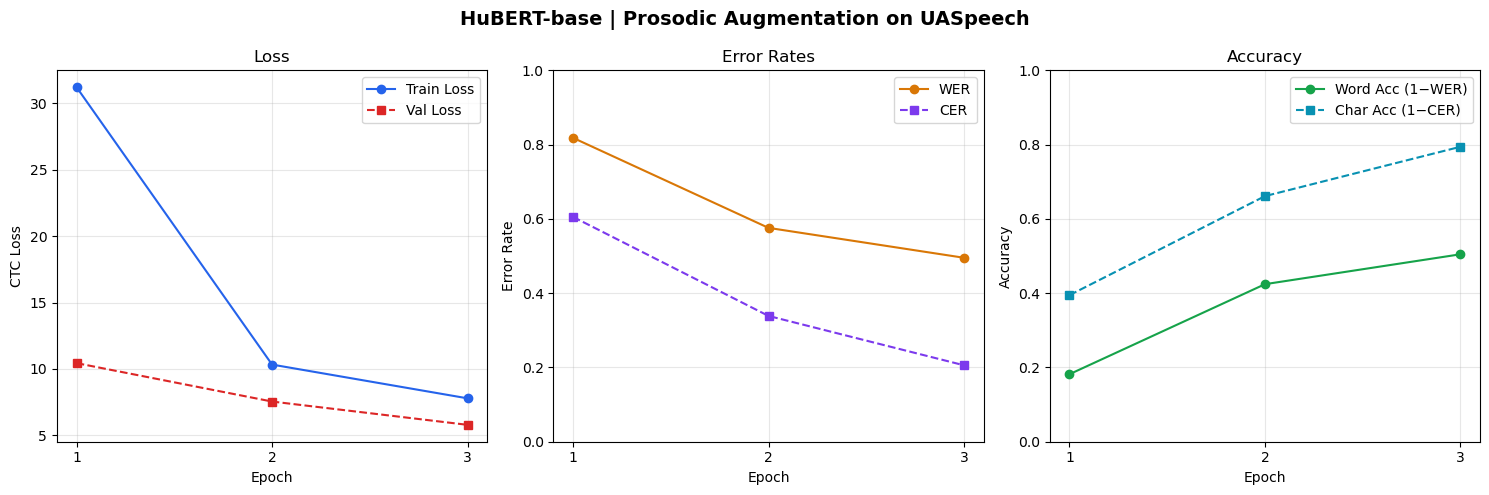

Saved → prosodic_training_curves.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("results.csv")
df["word_accuracy"] = 1 - df["wer"]
df["char_accuracy"] = 1 - df["cer"]
epochs = df["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("HuBERT-base | Prosodic Augmentation on UASpeech",
             fontsize=14, fontweight="bold")

axes[0].plot(epochs, df["train_loss"], "o-", label="Train Loss", color="#2563eb")
axes[0].plot(epochs, df["val_loss"],   "s--", label="Val Loss",  color="#dc2626")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(epochs, df["wer"], "o-", label="WER", color="#d97706")
axes[1].plot(epochs, df["cer"], "s--", label="CER", color="#7c3aed")
axes[1].set_title("Error Rates"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Error Rate"); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[2].plot(epochs, df["word_accuracy"], "o-", label="Word Acc (1−WER)", color="#16a34a")
axes[2].plot(epochs, df["char_accuracy"], "s--", label="Char Acc (1−CER)", color="#0891b2")
axes[2].set_title("Accuracy"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy"); axes[2].set_ylim(0, 1)
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("prosodic_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → prosodic_training_curves.png")